In [6]:
# imports and setup

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import librosa
import librosa.display
from tqdm import tqdm
import sys
import os

sys.path.append('..')
from minilearn.preprocessing.scaler import StandardScaler
from minilearn.preprocessing.split  import stratified_train_test_split

# load metadata from week 4
df = pd.read_csv('../outputs/metadata.csv')
print(f"Loaded {len(df)} files")
df.head()

Loaded 2452 files


,filepath,modality,channel,emotion,intensity,statement,repetition,actor,gender,label
0,../data/Actor_01\03-01-01-01-01-01-01.wav,3,1,1,1,1,1,1,male,neutral
1,../data/Actor_01\03-01-01-01-01-02-01.wav,3,1,1,1,1,2,1,male,neutral
2,../data/Actor_01\03-01-01-01-02-01-01.wav,3,1,1,1,2,1,1,male,neutral
3,../data/Actor_01\03-01-01-01-02-02-01.wav,3,1,1,1,2,2,1,male,neutral
4,../data/Actor_01\03-01-02-01-01-01-01.wav,3,1,2,1,1,1,1,male,calm


In [7]:
#understand what librosa gives before extracting

In [2]:
# pick one file
sample   = df[df['label'] == 'angry'].iloc[0]
y, sr    = librosa.load(sample['filepath'], sr=48000)

print(f"Audio array shape : {y.shape}")
print(f"Sample rate       : {sr}")
print(f"Duration          : {len(y)/sr:.2f} seconds")
print(f"Min amplitude     : {y.min():.4f}")
print(f"Max amplitude     : {y.max():.4f}")

# now look at what ONE feature looks like before summarising
mfcc = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=13)
print(f"\nRaw MFCC shape    : {mfcc.shape}")
print(f"  → {mfcc.shape[0]} coefficients × {mfcc.shape[1]} time frames")
print(f"\nMFCC mean shape   : {np.mean(mfcc, axis=1).shape}")
print(f"MFCC std shape    : {np.std(mfcc, axis=1).shape}")
print(f"Combined shape    : {np.concatenate([np.mean(mfcc, axis=1), np.std(mfcc, axis=1)]).shape}")

Audio array shape : (185786,)
Sample rate       : 48000
Duration          : 3.87 seconds
Min amplitude     : -0.1497
Max amplitude     : 0.1810

Raw MFCC shape    : (13, 363)
  → 13 coefficients × 363 time frames

MFCC mean shape   : (13,)
MFCC std shape    : (13,)
Combined shape    : (26,)


In [8]:
#visualise what each feature captures

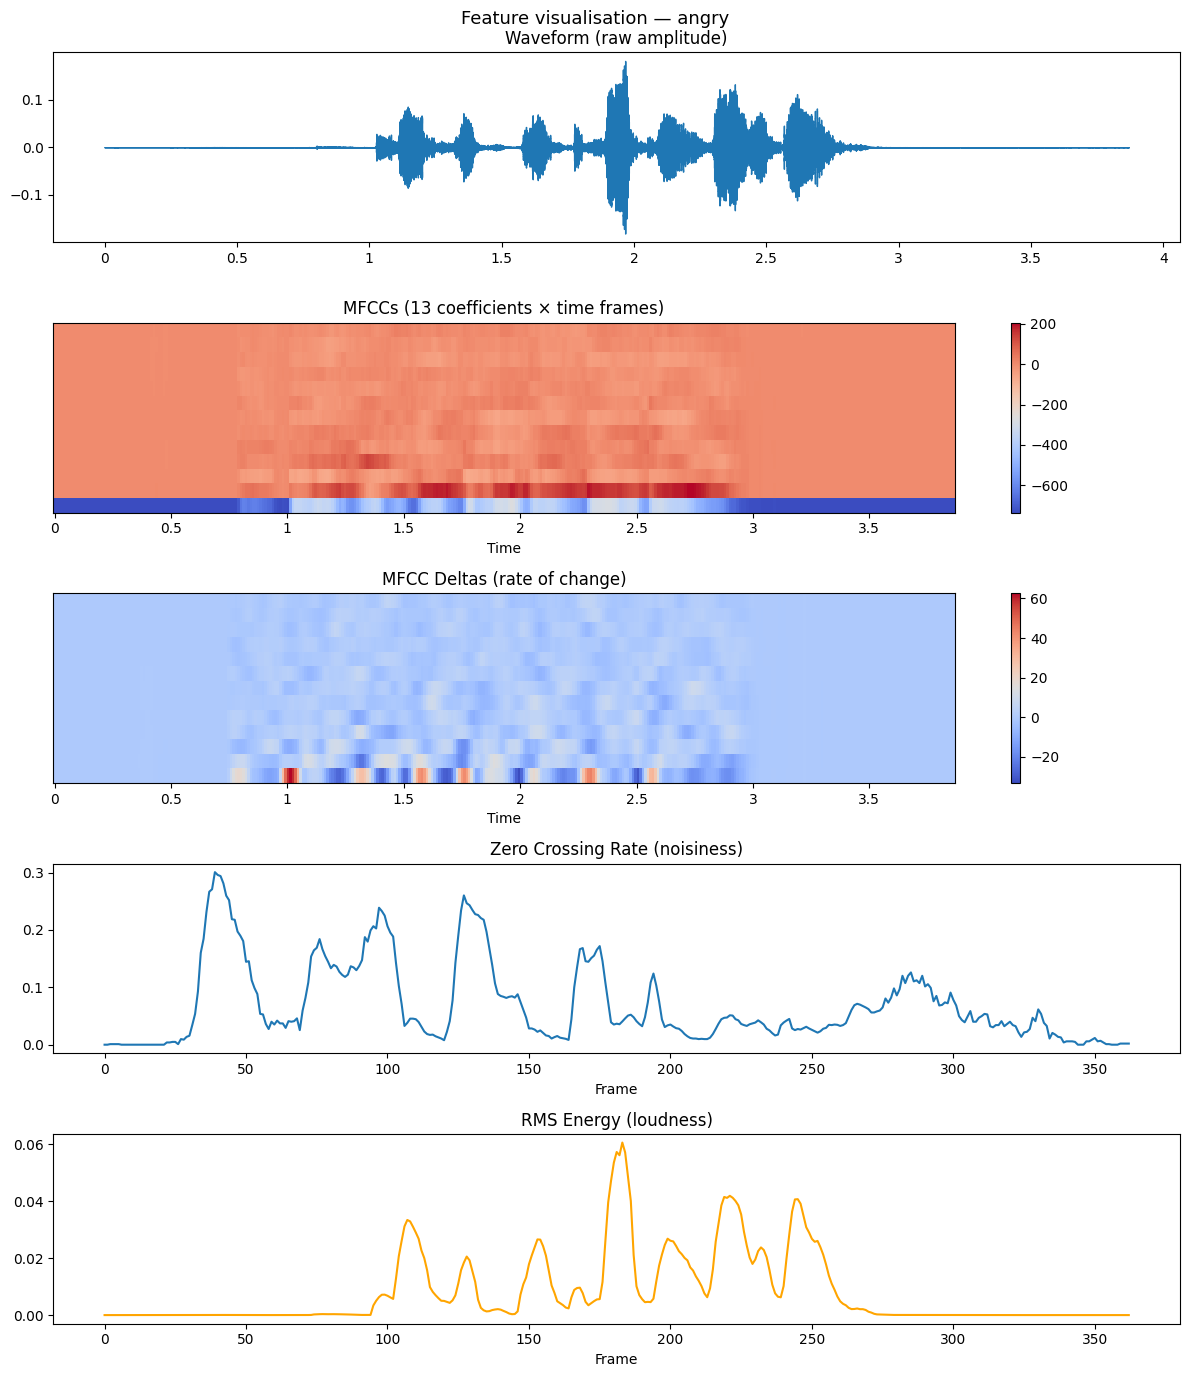

In [3]:
sample  = df[df['label'] == 'angry'].iloc[0]
y, sr   = librosa.load(sample['filepath'], sr=48000)

fig, axes = plt.subplots(5, 1, figsize=(12, 14))

# 1. waveform
librosa.display.waveshow(y, sr=sr, ax=axes[0])
axes[0].set_title('Waveform (raw amplitude)')
axes[0].set_xlabel('')

# 2. MFCCs
mfcc = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=13)
img  = librosa.display.specshow(mfcc, sr=sr, x_axis='time', ax=axes[1])
axes[1].set_title('MFCCs (13 coefficients × time frames)')
plt.colorbar(img, ax=axes[1])

# 3. MFCC deltas
mfcc_delta = librosa.feature.delta(mfcc)
img2 = librosa.display.specshow(mfcc_delta, sr=sr, x_axis='time', ax=axes[2])
axes[2].set_title('MFCC Deltas (rate of change)')
plt.colorbar(img2, ax=axes[2])

# 4. Zero crossing rate
zcr = librosa.feature.zero_crossing_rate(y)
axes[3].plot(zcr[0])
axes[3].set_title('Zero Crossing Rate (noisiness)')
axes[3].set_xlabel('Frame')

# 5. RMS Energy
rms = librosa.feature.rms(y=y)
axes[4].plot(rms[0], color='orange')
axes[4].set_title('RMS Energy (loudness)')
axes[4].set_xlabel('Frame')

plt.suptitle(f"Feature visualisation — {sample['label']}", fontsize=13)
plt.tight_layout()
plt.savefig('../outputs/feature_visualisation.png', dpi=150, bbox_inches='tight')
plt.show()

In [9]:
 the feature extraction function

SyntaxError: invalid syntax (2501231019.py, line 1)

In [4]:
def extract_features(filepath, sr=48000):
    """
    Extract a fixed-length feature vector from one audio file.

    Returns a 1D array of shape (112,) containing:
    - MFCCs mean+std          (26)
    - MFCC deltas mean+std    (26)
    - MFCC delta2 mean+std    (26)
    - Chroma mean+std         (24)
    - ZCR mean+std            ( 2)
    - RMS mean+std            ( 2)
    - Spectral centroid        ( 2)
    - Spectral bandwidth       ( 2)
    - Spectral rolloff         ( 2)
    Total                     112
    """
    y, sr = librosa.load(filepath, sr=sr)

    def summarise(feat):
        """Collapse (n_features, n_frames) → (2*n_features,) via mean+std."""
        return np.concatenate([
            np.mean(feat, axis=1),
            np.std(feat,  axis=1)
        ])

    # extract each feature
    mfcc        = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=13)
    mfcc_delta  = librosa.feature.delta(mfcc)
    mfcc_delta2 = librosa.feature.delta(mfcc, order=2)
    chroma      = librosa.feature.chroma_stft(y=y, sr=sr)
    zcr         = librosa.feature.zero_crossing_rate(y)
    rms         = librosa.feature.rms(y=y)
    spec_c      = librosa.feature.spectral_centroid(y=y, sr=sr)
    spec_bw     = librosa.feature.spectral_bandwidth(y=y, sr=sr)
    spec_ro     = librosa.feature.spectral_rolloff(y=y, sr=sr)

    vector = np.concatenate([
        summarise(mfcc),         # 13 mean + 13 std = 26
        summarise(mfcc_delta),   # 26
        summarise(mfcc_delta2),  # 26
        summarise(chroma),       # 12 mean + 12 std = 24
        summarise(zcr),          #  1 mean +  1 std =  2
        summarise(rms),          #  2
        summarise(spec_c),       #  2
        summarise(spec_bw),      #  2
        summarise(spec_ro),      #  2
    ])

    return vector                # shape (112,)

# test on one file before running on all
test_vec = extract_features(df.iloc[0]['filepath'])
print(f"Feature vector shape: {test_vec.shape}")
print(f"First 10 values: {test_vec[:10].round(3)}")
print(f"Any NaN: {np.isnan(test_vec).any()}")
print(f"Any Inf: {np.isinf(test_vec).any()}")

Feature vector shape: (112,)
First 10 values: [-726.217   68.541    3.293   12.205    5.51    13.667   -2.984    3.098
   -3.311   -1.564]
Any NaN: False
Any Inf: False


In [ ]:
 #extract from all files

In [5]:
os.makedirs('../outputs', exist_ok=True)

features = []
failed   = []

for idx, row in tqdm(df.iterrows(), total=len(df), desc='Extracting'):
    try:
        feat = extract_features(row['filepath'])

        # check for bad values immediately
        if np.isnan(feat).any() or np.isinf(feat).any():
            print(f"Bad values in: {row['filepath']}")
            feat = np.zeros(112)
            failed.append(idx)

        features.append(feat)

    except Exception as e:
        print(f"Failed [{idx}]: {row['filepath']} — {e}")
        features.append(np.zeros(112))
        failed.append(idx)

print(f"\nExtracted : {len(df) - len(failed)}/{len(df)}")
print(f"Failed    : {len(failed)}")
if failed:
    print(f"Failed indices: {failed}")

Extracting: 100%|██████████████████████████████████████████████████████████████████| 2452/2452 [11:17<00:00,  3.62it/s]


Extracted : 2452/2452
Failed    : 0


In [10]:
#build and save the feature dataframe:

In [11]:
# build feature column names
feat_names = (
    [f"mfcc_mean_{i}"       for i in range(13)] +
    [f"mfcc_std_{i}"        for i in range(13)] +
    [f"mfcc_d_mean_{i}"     for i in range(13)] +
    [f"mfcc_d_std_{i}"      for i in range(13)] +
    [f"mfcc_d2_mean_{i}"    for i in range(13)] +
    [f"mfcc_d2_std_{i}"     for i in range(13)] +
    [f"chroma_mean_{i}"     for i in range(12)] +
    [f"chroma_std_{i}"      for i in range(12)] +
    ['zcr_mean',  'zcr_std'  ] +
    ['rms_mean',  'rms_std'  ] +
    ['spec_c_mean',  'spec_c_std' ] +
    ['spec_bw_mean', 'spec_bw_std'] +
    ['spec_ro_mean', 'spec_ro_std']
)

print(f"Feature names count: {len(feat_names)}")  # should be 112

# build dataframe
X_df = pd.DataFrame(np.stack(features), columns=feat_names)

# attach metadata
meta = df[['emotion', 'label', 'channel', 'actor',
           'gender', 'intensity']].reset_index(drop=True)
out_df = pd.concat([meta, X_df], axis=1)

# save
out_df.to_csv('../outputs/features.csv', index=False)
print(f"Saved features.csv — shape: {out_df.shape}")
out_df.head()

Feature names count: 112
Saved features.csv — shape: (2452, 118)


,emotion,label,channel,actor,gender,intensity,mfcc_mean_0,mfcc_mean_1,mfcc_mean_2,mfcc_mean_3,...,zcr_mean,zcr_std,rms_mean,rms_std,spec_c_mean,spec_c_std,spec_bw_mean,spec_bw_std,spec_ro_mean,spec_ro_std
0,1,neutral,1,1,male,1,-726.217224,68.541420,3.293398,12.205300,...,0.050476,0.055781,0.002120,0.003391,7416.297748,4428.027505,5551.291828,1966.670942,13285.735887,7873.634242
1,1,neutral,1,1,male,1,-719.128296,70.201569,1.168397,13.122541,...,0.052904,0.048074,0.002258,0.003638,7135.571471,4196.796437,5653.771579,1897.506371,13191.643371,7634.107567
2,1,neutral,1,1,male,1,-714.995728,69.689346,3.924564,11.924190,...,0.046627,0.048342,0.002707,0.004298,7239.265648,4333.681827,5641.048020,2054.943735,13279.137826,7981.393363
3,1,neutral,1,1,male,1,-710.975281,67.564880,5.782240,13.230727,...,0.053835,0.051899,0.002521,0.004178,7008.958169,3975.417498,5802.315322,1915.796134,13272.074245,7570.671093
4,2,calm,1,1,male,1,-759.921753,75.783524,6.023605,14.557394,...,0.045929,0.051376,0.001579,0.002497,6997.311810,4373.360791,5518.637359,1916.039762,12649.543486,7902.073642


In [12]:
#feature analysis 

In [13]:
# reload to verify save worked
out_df     = pd.read_csv('../outputs/features.csv')
feat_cols  = [c for c in out_df.columns if c not in
              ['emotion','label','channel','actor','gender','intensity']]
X          = out_df[feat_cols].values
y          = out_df['emotion'].values

print(f"X shape : {X.shape}")
print(f"y shape : {y.shape}")
print(f"\nNaN count : {np.isnan(X).sum()}")
print(f"Inf count : {np.isinf(X).sum()}")

# feature value ranges — shows why scaling is critical
ranges = pd.DataFrame({
    'min'  : X.min(axis=0),
    'max'  : X.max(axis=0),
    'mean' : X.mean(axis=0),
    'std'  : X.std(axis=0)
}, index=feat_cols)

print("\nFeature ranges (first 10):")
print(ranges.head(10).round(3))
print("\nFeature ranges (last 5):")
print(ranges.tail(5).round(3))

X shape : (2452, 112)
y shape : (2452,)

NaN count : 0
Inf count : 0

Feature ranges (first 10):
                 min      max     mean     std
mfcc_mean_0 -873.242 -333.378 -593.934  96.205
mfcc_mean_1   18.962  122.646   69.972  17.407
mfcc_mean_2  -53.823   22.604   -9.788  13.366
mfcc_mean_3  -17.509   36.563    9.419   7.818
mfcc_mean_4  -27.002   21.130   -1.181   7.442
mfcc_mean_5  -15.661   27.950    6.587   7.988
mfcc_mean_6  -34.597   10.093  -11.141   7.361
mfcc_mean_7  -22.314   16.410   -0.680   5.540
mfcc_mean_8  -21.520    7.116   -7.351   4.923
mfcc_mean_9  -26.877    7.422   -7.580   5.615

Feature ranges (last 5):
                   min        max       mean       std
spec_c_std    1491.341   4819.783   3365.453   580.361
spec_bw_mean  2708.036   6368.165   4791.561   604.938
spec_bw_std    672.274   2859.818   2010.376   317.599
spec_ro_mean  4172.679  14629.598  10046.141  1682.705
spec_ro_std   2958.945   8521.385   6686.614   896.146


In [14]:
#feature distribution by emotion

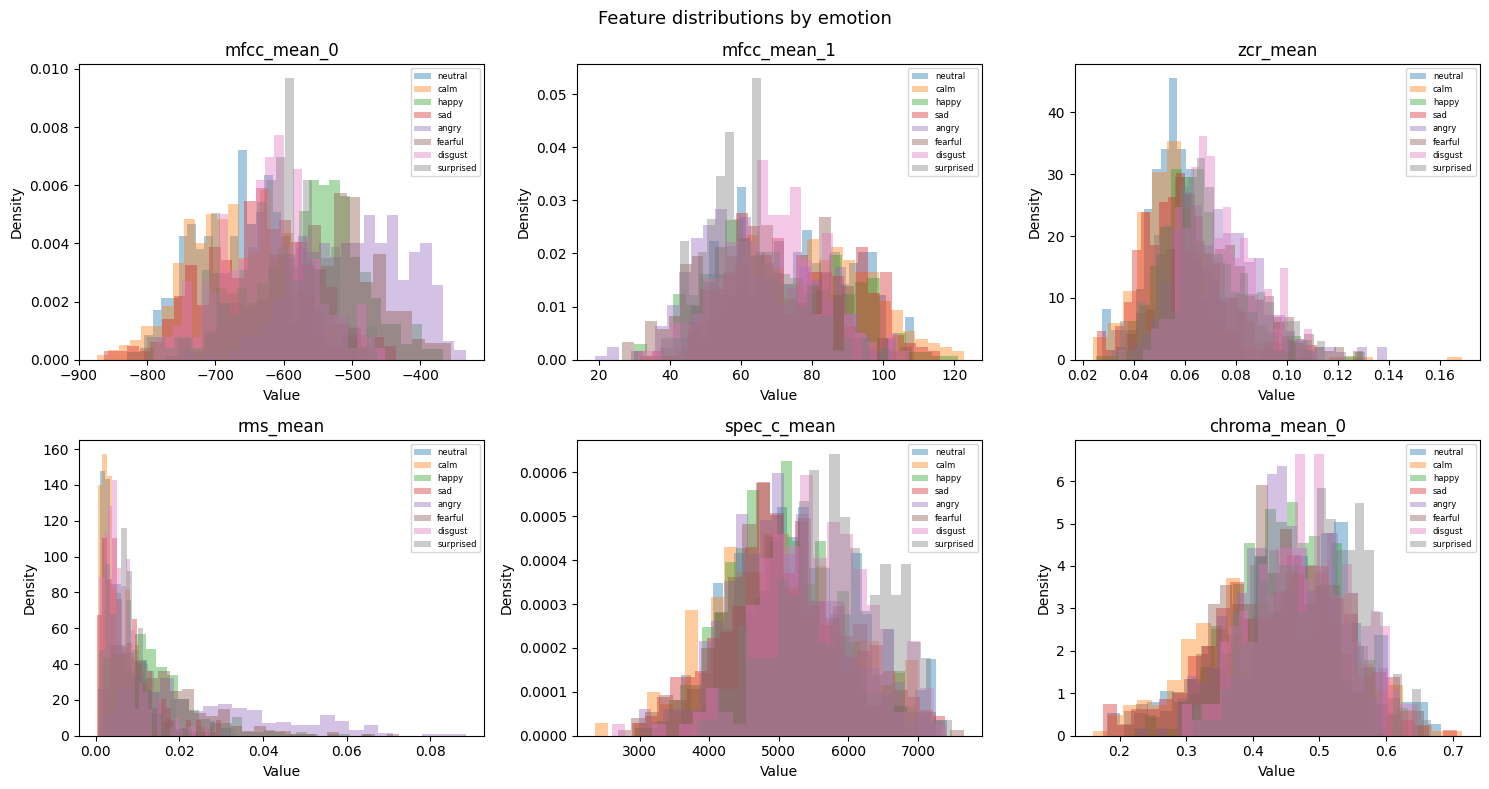

In [15]:
# pick 6 meaningful features to visualise
plot_features = [
    'mfcc_mean_0',    # overall energy
    'mfcc_mean_1',    # spectral tilt
    'zcr_mean',       # noisiness
    'rms_mean',       # loudness
    'spec_c_mean',    # brightness
    'chroma_mean_0'   # tonal content
]

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for ax, feat in zip(axes, plot_features):
    for emotion in out_df['label'].unique():
        mask   = out_df['label'] == emotion
        values = out_df.loc[mask, feat]
        ax.hist(values, bins=25, alpha=0.4,
                label=emotion, density=True)
    ax.set_title(feat)
    ax.set_xlabel('Value')
    ax.set_ylabel('Density')
    ax.legend(fontsize=6)

plt.suptitle('Feature distributions by emotion', fontsize=13)
plt.tight_layout()
plt.savefig('../outputs/feature_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

In [16]:
#correlation heatmap

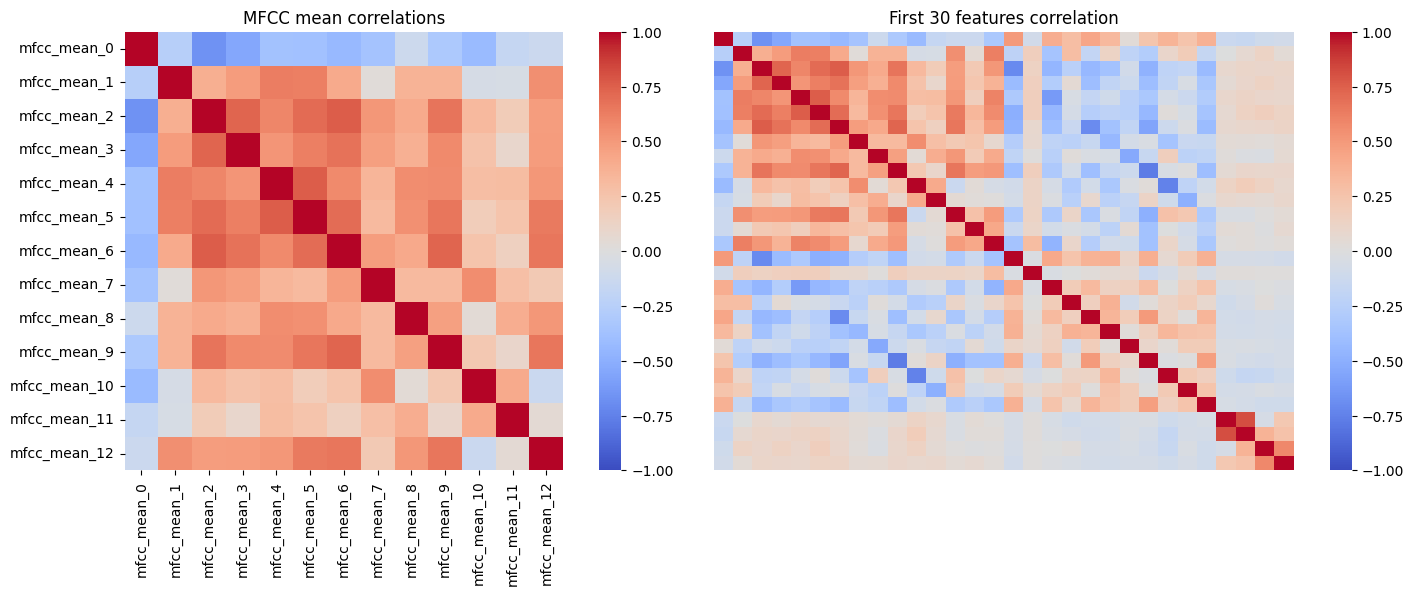

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# MFCC correlations
mfcc_cols = [c for c in feat_cols if 'mfcc_mean' in c]
corr_mfcc = out_df[mfcc_cols].corr()
sns.heatmap(corr_mfcc, cmap='coolwarm', center=0,
            vmin=-1, vmax=1, ax=axes[0], square=True)
axes[0].set_title('MFCC mean correlations')

# all feature correlations (sample 30)
sample_cols = feat_cols[:30]
corr_all    = out_df[sample_cols].corr()
sns.heatmap(corr_all, cmap='coolwarm', center=0,
            vmin=-1, vmax=1, ax=axes[1],
            xticklabels=False, yticklabels=False)
axes[1].set_title('First 30 features correlation')

plt.tight_layout()
plt.savefig('../outputs/feature_correlation.png', dpi=150, bbox_inches='tight')
plt.show()

In [18]:
#mean feature value per emotion

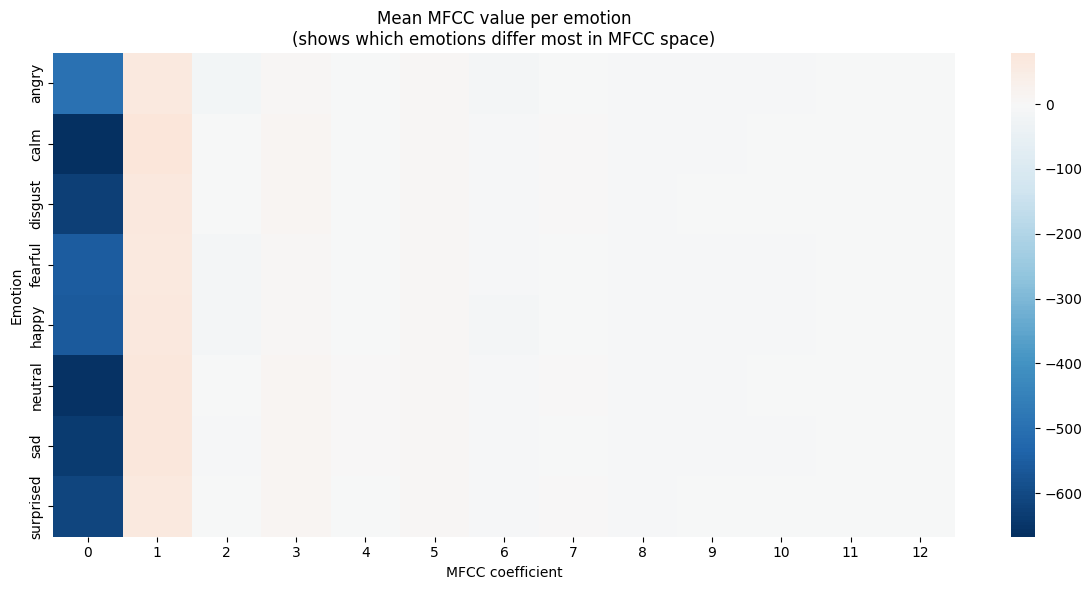

In [19]:
# average value of each feature group per emotion
mfcc_mean_cols = [c for c in feat_cols if 'mfcc_mean' in c]

emotion_means = out_df.groupby('label')[mfcc_mean_cols].mean()

plt.figure(figsize=(12, 6))
sns.heatmap(emotion_means, cmap='RdBu_r', center=0,
            xticklabels=[c.replace('mfcc_mean_','') for c in mfcc_mean_cols])
plt.title('Mean MFCC value per emotion\n(shows which emotions differ most in MFCC space)')
plt.xlabel('MFCC coefficient')
plt.ylabel('Emotion')
plt.tight_layout()
plt.savefig('../outputs/emotion_mfcc_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

In [20]:
# split and scale

In [21]:
from minilearn.preprocessing.split  import stratified_train_test_split
from minilearn.preprocessing.scaler import StandardScaler

X = out_df[feat_cols].values.astype(float)
y = out_df['emotion'].values

# stratified split
X_train, X_test, y_train, y_test = stratified_train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"Train size : {X_train.shape}")
print(f"Test size  : {X_test.shape}")

# verify stratification worked
print("\nClass proportions:")
print(f"{'Emotion':10s}  {'Total':>6}  {'Train':>6}  {'Test':>5}  {'Test%':>6}")
for cls in np.unique(y):
    total = (y      == cls).sum()
    train = (y_train == cls).sum()
    test  = (y_test  == cls).sum()
    print(f"{cls:10d}  {total:6d}  {train:6d}  {test:5d}  {test/total:6.1%}")

# scale — fit on train ONLY
scaler     = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

# sanity check
print(f"\nAfter scaling:")
print(f"Train mean : {X_train_sc.mean():.6f}   (should be ~0)")
print(f"Train std  : {X_train_sc.std():.6f}    (should be ~1)")
print(f"Test mean  : {X_test_sc.mean():.4f}    (won't be exactly 0 — that's fine)")

Train size : (1956, 112)
Test size  : (496, 112)

Class proportions:
Emotion      Total   Train   Test   Test%
         1     188     150     38   20.2%
         2     376     300     76   20.2%
         3     376     300     76   20.2%
         4     376     300     76   20.2%
         5     376     300     76   20.2%
         6     376     300     76   20.2%
         7     192     153     39   20.3%
         8     192     153     39   20.3%

After scaling:
Train mean : -0.000000   (should be ~0)
Train std  : 1.000000    (should be ~1)
Test mean  : 0.0038    (won't be exactly 0 — that's fine)


In [22]:
#save everything for classifiers

In [24]:
os.makedirs('../outputs', exist_ok=True)

np.save('../outputs/X_train_sc.npy', X_train_sc)
np.save('../outputs/X_test_sc.npy',  X_test_sc)
np.save('../outputs/y_train.npy',    y_train)
np.save('../outputs/y_test.npy',     y_test)

# also save the scaler parameters so you can reuse it
np.save('../outputs/scaler_mean.npy', scaler.mean_)
np.save('../outputs/scaler_std.npy',  scaler.std_)

# save feature names for later plots
pd.Series(feat_cols).to_csv('../outputs/feature_names.csv', index=False)

print("Saved:")
print(f"  X_train_sc : {X_train_sc.shape}")
print(f"  X_test_sc  : {X_test_sc.shape}")
print(f"  y_train    : {y_train.shape}")
print(f"  y_test     : {y_test.shape}")


Saved:
  X_train_sc : (1956, 112)
  X_test_sc  : (496, 112)
  y_train    : (1956,)
  y_test     : (496,)
